# Decide \> Decision Analysis

Create, solve, and stress-test a decision tree using expected monetary
value.

Decision analysis is useful when a manager must choose between actions
whose payoffs depend on uncertain outcomes. The workflow is:

1.  Write the decision structure as a tree.
2.  Assign probabilities to chance branches and payoffs to terminal
    outcomes.
3.  Fold the tree back from right to left to calculate expected monetary
    value (EMV).
4.  Choose the branch with the best EMV at each decision node.
5.  Use sensitivity analysis to check whether the recommendation depends
    on fragile assumptions.

Radiant presents this under *Model \> Decide \> Decision analysis*. In
Python the corresponding API is `rsm.decide.dtree`.

In [1]:
import polars as pl
import pyrsm as rsm
import matplotlib.pyplot as plt
from IPython.display import Markdown

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Example 1: Sign a Contract

The tree below follows the example in the Radiant documentation. The
first node is a decision node: sign with a movie company or sign with a
TV network. The movie-company option has uncertain box-office outcomes
and a legal cost. The TV-network option has a fixed payoff.

Indentation matters. Each branch name ends with `:` and the information
for that branch is indented underneath it.

In [3]:
contract_yaml = """
name: Sign contract
variables:
    legal fees: 5000
    P(small): 0.3
    P(medium): 0.6
    P(large): 1 - P(small) - P(medium)
type: decision
Sign with Movie Company:
    cost: legal fees
    type: chance
    Small Box Office:
        p: P(small)
        payoff: 200000
    Medium Box Office:
        p: P(medium)
        payoff: 1000000
    Large Box Office:
        p: P(large)
        payoff: 3000000
Sign with TV Network:
    payoff: 900000
"""

In [4]:
tree = rsm.decide.dtree(contract_yaml, opt="max")
tree.summary(input=True, output=True)

Decision tree input:

name: Sign contract
variables:
    legal fees: 5000
    P(small): 0.3
    P(medium): 0.6
    P(large): 1 - P(small) - P(medium)
type: decision
Sign with Movie Company:
    cost: legal fees
    type: chance
    Small Box Office:
        p: P(small)
        payoff: 200000
    Medium Box Office:
        p: P(medium)
        payoff: 1000000
    Large Box Office:
        p: P(large)
        payoff: 3000000
Sign with TV Network:
    payoff: 900000

Variable values:
  legal fees: 5000.00
  P(small): 0.30
  P(medium): 0.60
  P(large): 0.10

Optimization direction: max
Root payoff ('Sign contract'): 955,000.00

Initial decision tree:
  [D] Sign contract
    (C) Sign with Movie Company  cost=5,000.00
       T  Small Box Office  p=0.3000  payoff=200,000.00
       T  Medium Box Office  p=0.6000  payoff=1,000,000.00
       T  Large Box Office  p=0.1000  payoff=3,000,000.00
     T  Sign with TV Network  payoff=900,000.00

Final decision tree:
  [D] Sign contract  payoff=955,000

### Reading the Result

The movie-company branch has an expected box-office payoff of:

$$
0.3 \times 200{,}000 + 0.6 \times 1{,}000{,}000 + 0.1 \times 3{,}000{,}000 = 960{,}000
$$

After subtracting legal fees, the movie-company EMV is 955,000. The
TV-network branch pays 900,000. Because this is a maximization problem,
the optimal decision is to sign with the movie company.

In [5]:
movie_ev = (
    tree.vars["P(small)"] * 200_000
    + tree.vars["P(medium)"] * 1_000_000
    + tree.vars["P(large)"] * 3_000_000
    - tree.vars["legal fees"]
)
tv_ev = 900_000
pl.DataFrame(
    {
        "option": ["Sign with Movie Company", "Sign with TV Network"],
        "emv": [movie_ev, tv_ev],
    }
)

The solution table gives one row per node. Terminal nodes hold observed
payoffs, chance nodes hold expected payoffs, and decision nodes hold the
selected branch value.

In [6]:
pl.from_pandas(tree.solution_df)

## Visualizing the Tree

`to_mermaid()` returns Mermaid flowchart source for the initial or final
tree. In the final tree, chosen decision branches use a thicker
connection.

In [7]:
fence = "`" * 3
Markdown(f"{fence}mermaid\n{tree.to_mermaid(final=False, symbol='$')}\n{fence}")

In [8]:
fence = "`" * 3
Markdown(f"{fence}mermaid\n{tree.to_mermaid(final=True, symbol='$')}\n{fence}")

## Sensitivity Analysis

The recommendation may depend on the cost of legal support. Sensitivity
analysis reruns the tree after replacing one or more values in the
`variables:` block. Here we evaluate legal fees from 0 to 80,000 in
steps of 10,000.

In [9]:
sensitivity = tree.sensitivity(
    {"legal fees": {"min": 0, "max": 80_000, "step": 10_000}}
)
sensitivity_table = pl.from_pandas(sensitivity.to_frame())
sensitivity_table

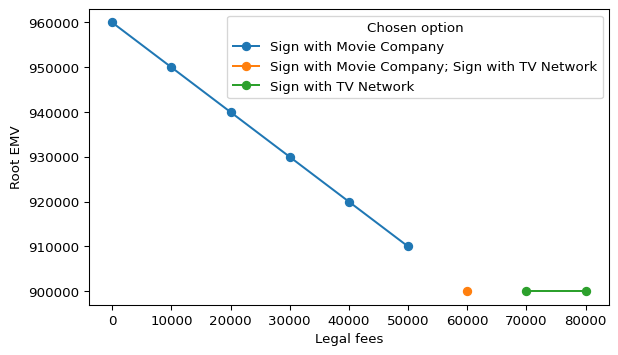

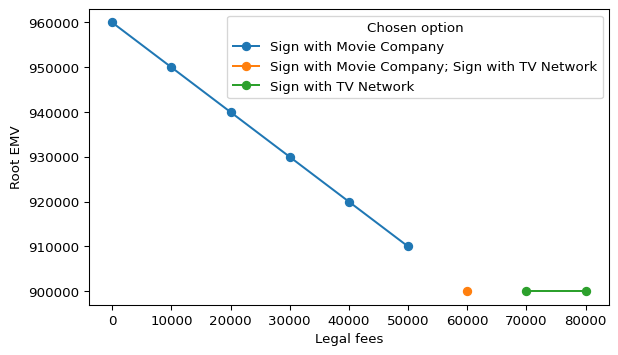

In [10]:
sensitivity_pdf = sensitivity_table.to_pandas()
fig, ax = plt.subplots(figsize=(7, 4))
for chosen, group in sensitivity_pdf.groupby("chosen"):
    ax.plot(group["legal fees"], group["payoff"], marker="o", label=chosen)
ax.set_xlabel("Legal fees")
ax.set_ylabel("Root EMV")
ax.legend(title="Chosen option")
fig

In [11]:
sensitivity.threshold_flips()

[{'variable': 'legal fees',
  'from_value': 50000.0,
  'to_value': 60000.0,
  'from_chosen': ['Sign with Movie Company'],
  'to_chosen': ['Sign with Movie Company', 'Sign with TV Network']},
 {'variable': 'legal fees',
  'from_value': 60000.0,
  'to_value': 70000.0,
  'from_chosen': ['Sign with Movie Company', 'Sign with TV Network'],
  'to_chosen': ['Sign with TV Network']}]

The table and plot show when the preferred decision changes. In this
example, the movie-company option is preferred at low legal-fee levels,
but the TV-network option becomes better once legal fees are high
enough.

## Referencing a Subtree

Large decision problems are easier to maintain when repeated logic is
stored in a separate tree. In Python, a tree can reference another
solved tree using `subtree("name")` in the `variables:` block or in a
node payoff. The `subtree_library` argument maps those names to solved
`dtree` objects.

In [12]:
tuesday_yaml = """
name: Tuesday launch
type: decision
Promote heavily:
    payoff: 120000
Hold budget:
    payoff: 60000
"""

tuesday = rsm.decide.dtree(tuesday_yaml)
tuesday.payoff

120000.0

In [13]:
monday_yaml = """
name: Monday launch
variables:
    tuesday value: subtree("Tuesday launch")
type: decision
Launch Monday:
    type: chance
    Strong demand:
        p: 0.4
        payoff: 300000 + tuesday value
    Weak demand:
        p: 0.6
        payoff: 50000 + tuesday value
Wait:
    payoff: tuesday value
"""

monday = rsm.decide.dtree(
    monday_yaml,
    subtree_library={"Tuesday launch": tuesday},
)
monday.summary(input=False, output=True)

Variable values:
  tuesday value: 120000.00

Optimization direction: max
Root payoff ('Monday launch'): 270,000.00

Initial decision tree:
  [D] Monday launch
    (C) Launch Monday
       T  Strong demand  p=0.4000  payoff=420,000.00
       T  Weak demand  p=0.6000  payoff=170,000.00
     T  Wait  payoff=120,000.00

Final decision tree:
  [D] Monday launch  payoff=270,000.00
    (C) Launch Monday  payoff=270,000.00
       T  Strong demand  p=0.4000  payoff=420,000.00
       T  Weak demand  p=0.6000  payoff=170,000.00
     T  Wait  payoff=120,000.00

Subtrees are useful when a later-stage decision appears in several
places or when students need to debug a complex problem one piece at a
time.

## Key Objects

-   `rsm.decide.dtree(yaml_text, opt="max")` solves a decision tree.
-   `tree.solution_df` stores the solved node table.
-   `tree.to_mermaid(final=True)` returns graph source for the
    folded-back tree.
-   `tree.sensitivity(...)` evaluates how decisions change as variable
    assumptions change.
-   `tree.python_code` stores a reproducible Python snippet for the
    analysis.